# Ion Traps with QuTiP

**Simulating trapped-ion quantum computers from first principles**

This notebook walks through the [presentation slides](Ion%20Traps%20with%20QuTiP.pdf) using TIQS.

## 1. Bell state in 10 lines

Two Ca-40 ions. One perfect Bell state. 34 modules, 178 tests underneath.

In [1]:
from tiqs import PaulTrap, SimulationConfig, SimulationRunner, get_species
from tiqs.analysis.fidelity import bell_state_fidelity

TWO_PI = 2 * 3.141592653589793
species = get_species("Ca40")
trap = PaulTrap(v_rf=300, omega_rf=TWO_PI * 30e6, r0=0.5e-3, omega_axial=TWO_PI * 1e6, species=species)
config = SimulationConfig(species=species, trap=trap, n_ions=2, n_modes=1, n_fock=15)
runner = SimulationRunner(config)
result = runner.run_ms_gate(ions=[0, 1])
print(bell_state_fidelity(result.states[-1].ptrace([0, 1])))

0.9999999999999947


/Users/churchill/GitHub/qutip-trapped-ion-qc/.venv/lib/python3.14/site-packages/qutip/core/coefficient.py:424: UserWarning: `cython`, `setuptools` and `filelock` are required for compilation of string coefficents. Falling back on `eval`.
  warnings.warn(


## 2. The Paul trap

QuTiP doesn't care about traps - but to build correct Hamiltonians, you need correct frequencies.

In [2]:
print(f"Mathieu q:       {trap.mathieu_q:.3f}")
print(f"Radial secular:  2pi x {trap.omega_radial / TWO_PI / 1e6:.3f} MHz")
print(f"Stable:          {trap.is_stable()}")

Mathieu q:       0.163
Radial secular:  2pi x 1.579 MHz
Stable:          True


## 3. Coulomb crystals and normal modes

Two Ca-40 ions at 1 MHz axial frequency sit ~5.6 um apart. The stretch-to-COM frequency ratio is exactly sqrt(3).

In [3]:
import numpy as np
from tiqs import normal_modes

modes = normal_modes(2, trap)
print(f"Positions: {modes.positions * 1e6} um")
print(f"COM ratio:     {modes.axial_freqs[0] / trap.omega_axial:.6f}")
print(f"Stretch ratio: {modes.axial_freqs[1] / trap.omega_axial:.6f}")
print(f"sqrt(3):       {np.sqrt(3):.6f}")

Positions: [-2.80272127  2.80272127] um
COM ratio:     1.000000
Stretch ratio: 1.732051
sqrt(3):       1.732051


## 4. The Lamb-Dicke parameter

The single most important number in trapped-ion physics:
$\eta_{i,m} = k_\text{eff} \cdot b_{i,m} \cdot \sqrt{\hbar / (2 m \omega_m)}$

In [4]:
from tiqs import lamb_dicke_parameters

k_eff = TWO_PI / 729e-9  # Ca-40 qubit laser
eta = lamb_dicke_parameters(modes, species, k_eff, "axial")
print(f"Lamb-Dicke parameters (2 ions, 2 axial modes):")
print(f"  eta = {np.round(eta, 3)}")
print(f"\nCOM mode: same sign  - both ions couple equally")
print(f"Stretch mode: opposite signs - makes the entangling gate work")

Lamb-Dicke parameters (2 ions, 2 axial modes):
  eta = [[-0.069 -0.052]
 [-0.069  0.052]]

COM mode: same sign  - both ions couple equally
Stretch mode: opposite signs - makes the entangling gate work


## 5. Carrier Rabi oscillations

$H = (\Omega/2) \sigma_x$. Starting from $|0\rangle$, the expectation value oscillates as $\cos(\Omega t)$.

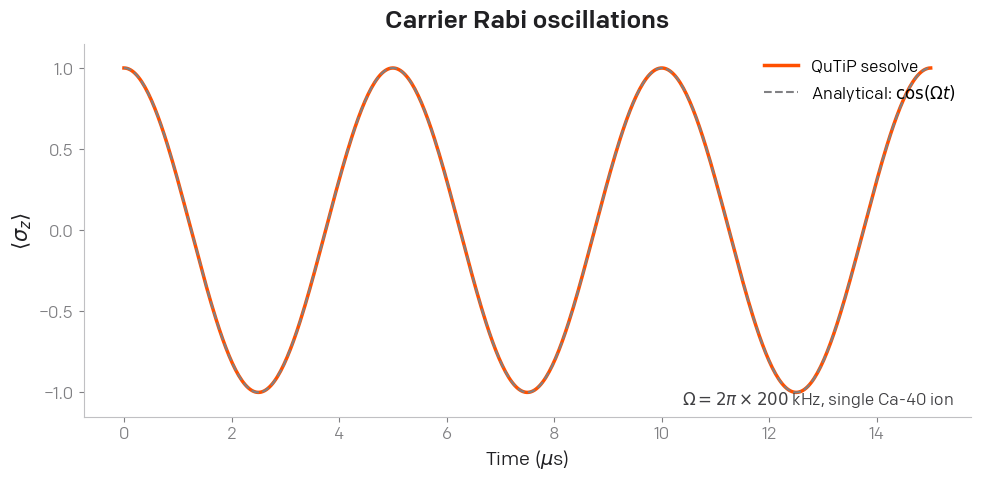

In [5]:
import qutip
import matplotlib as mpl
import matplotlib.pyplot as plt
from tiqs import HilbertSpace, OperatorFactory, StateFactory
from tiqs.interaction.hamiltonian import carrier_hamiltonian

IONQ_ORANGE = "#FF5000"
IONQ_MEDIUM_ORANGE = "#FF8200"
IONQ_LIGHT_ORANGE = "#FFB600"
IONQ_DARK = "#11191F"
IONQ_BLACK = "#202023"
IONQ_DARK_GREY = "#404043"
IONQ_GREY = "#808083"
IONQ_LIGHT_GREY = "#C0C0C3"
IONQ_LIGHTER_GREY = "#E0E0E3"
IONQ_WHITE = "#FFFFFF"
PALETTE = [IONQ_ORANGE, IONQ_DARK, IONQ_MEDIUM_ORANGE, IONQ_GREY, IONQ_LIGHT_ORANGE]

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Colfax", "Helvetica Neue", "Helvetica", "DejaVu Sans"],
    "font.size": 13, "axes.titlesize": 18, "axes.titleweight": "medium",
    "axes.labelsize": 14, "axes.labelweight": "regular",
    "axes.labelcolor": IONQ_BLACK,
    "axes.edgecolor": IONQ_LIGHT_GREY, "axes.facecolor": IONQ_WHITE,
    "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
    "xtick.color": IONQ_GREY, "ytick.color": IONQ_GREY,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "figure.facecolor": IONQ_WHITE,
    "legend.frameon": False, "legend.fontsize": 12,
    "lines.linewidth": 2.0, "lines.antialiased": True,
    "patch.edgecolor": IONQ_LIGHT_GREY,
    "grid.color": IONQ_LIGHTER_GREY, "grid.linewidth": 0.5,
})

hs = HilbertSpace(n_ions=2, n_modes=1, n_fock=15)
ops = OperatorFactory(hs)
sf = StateFactory(hs)

Omega = TWO_PI * 200e3
H = carrier_hamiltonian(ops, ion=0, rabi_frequency=Omega)
psi0 = sf.ground_state()
tlist = np.linspace(0, 3 * TWO_PI / Omega, 500)
result = qutip.sesolve(H, psi0, tlist, e_ops=[ops.sigma_z(0)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tlist * 1e6, result.expect[0], color=IONQ_ORANGE, linewidth=2.5,
        label="QuTiP sesolve", zorder=2)
ax.plot(tlist * 1e6, np.cos(Omega * tlist), "--", color=IONQ_GREY, linewidth=1.5,
        label=r"Analytical: $\cos(\Omega t)$", zorder=3)
ax.set_xlabel(r"Time ($\mu$s)", fontsize=14)
ax.set_ylabel(r"$\langle \sigma_z \rangle$", fontsize=15)
ax.set_title("Carrier Rabi oscillations", fontsize=18, fontweight="medium",
             color=IONQ_BLACK, pad=12)
ax.set_ylim(-1.15, 1.15)
ax.legend(loc="upper right", fontsize=12)
ax.text(0.98, 0.02, r"$\Omega = 2\pi \times 200$ kHz, single Ca-40 ion",
        transform=ax.transAxes, fontsize=12, color=IONQ_DARK_GREY,
        ha="right", va="bottom")
plt.tight_layout()
plt.show()

## 6. The Molmer-Sorensen gate

Spin-dependent force displaces the motional mode in opposite directions for different $\sigma_x$ eigenstates, tracing circles in phase space. The condition $\eta \Omega = \delta/4$ ensures the geometric phase accumulates to $\pi/4$ after one loop ($\tau = 2\pi/\delta$).

Result: $(|00\rangle + i|11\rangle) / \sqrt{2}$

In [6]:
from tiqs.gates.molmer_sorensen import ms_gate_hamiltonian, ms_gate_duration

hs2 = HilbertSpace(n_ions=2, n_modes=1, n_fock=20)
ops2 = OperatorFactory(hs2)
sf2 = StateFactory(hs2)

eta_val = 0.05
delta = TWO_PI * 15e3  # 15 kHz detuning from sideband
Omega_ms = delta / (4 * eta_val)  # 75 kHz - maximally entangling
tau = ms_gate_duration(delta)  # ~66.7 us
print(f"Gate duration: {tau * 1e6:.1f} us")

H_ms = ms_gate_hamiltonian(ops2, [0, 1], 0, [eta_val, eta_val], Omega_ms, delta)
tlist_ms = np.linspace(0, tau, 500)
result_ms = qutip.sesolve(H_ms, sf2.ground_state(), tlist_ms, options={"max_step": tau / 100})

fidelity = bell_state_fidelity(result_ms.states[-1].ptrace([0, 1]))
print(f"Bell state fidelity: {fidelity:.10f}")

Gate duration: 66.7 us
Bell state fidelity: 1.0000000238


### Phase-space trajectory and fidelity evolution

The $|{++}\rangle_x$ spin branch traces a circle of radius $2\eta\Omega/\delta$ in motional phase space. The fidelity dips to ~0.56 at the halfway point and recovers to 1.0 when the loop closes.

/Users/churchill/GitHub/qutip-trapped-ion-qc/.venv/lib/python3.14/site-packages/qutip/core/data/expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


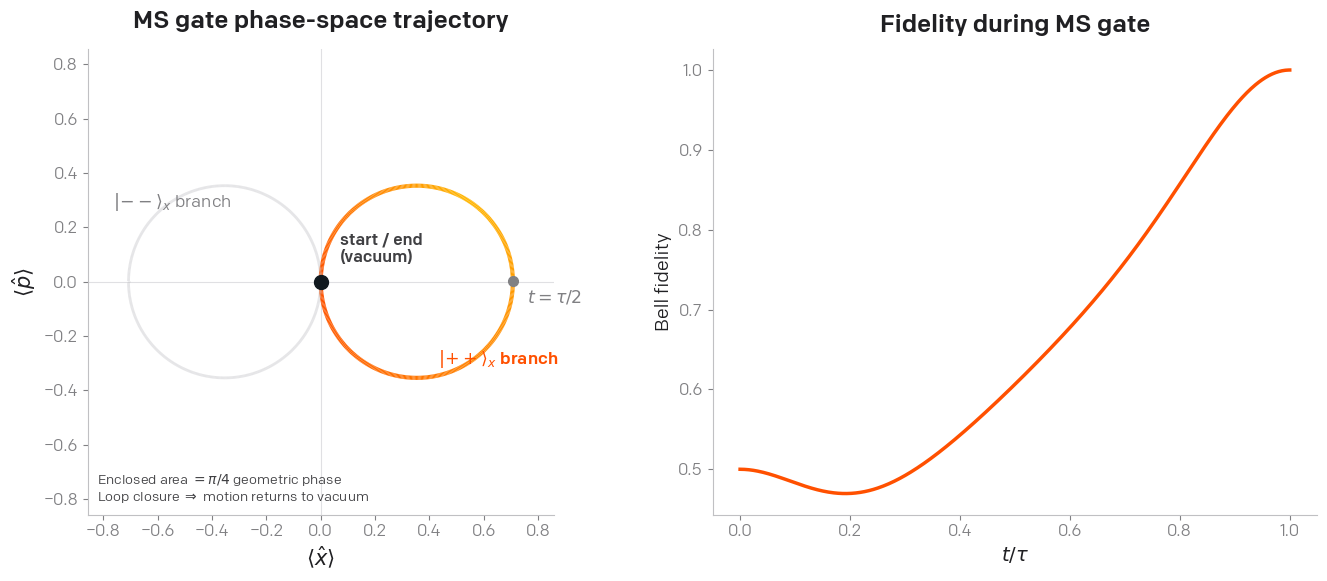

In [7]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

# Simulate the |++>_x branch as a forced oscillator (same approach as Figure 1)
n_fock_ps = 30
F = eta_val * Omega_ms  # coupling per spin eigenvalue
a_ps = qutip.destroy(n_fock_ps)
x_op = (a_ps + a_ps.dag()) / np.sqrt(2)
p_op = 1j * (a_ps.dag() - a_ps) / np.sqrt(2)

H_branch = [[F * a_ps.dag(), f"exp(1j*{delta}*t)"],
            [F * a_ps, f"exp(-1j*{delta}*t)"]]
res_branch = qutip.sesolve(H_branch, qutip.basis(n_fock_ps, 0), tlist_ms,
                           e_ops=[x_op, p_op], options={"max_step": tau / 200})
x_vals = np.real(res_branch.expect[0])
p_vals = np.real(res_branch.expect[1])

# Bell fidelity over time (from the full MS gate simulation)
fidelities = [bell_state_fidelity(s.ptrace([0, 1])) for s in result_ms.states]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Phase-space trajectory with time-gradient coloring (Figure 1 style)
t_norm = tlist_ms / tau
points = np.array([x_vals, p_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
ionq_cmap = LinearSegmentedColormap.from_list(
    "ionq", [IONQ_ORANGE, IONQ_MEDIUM_ORANGE, IONQ_LIGHT_ORANGE, IONQ_ORANGE])
lc = LineCollection(segments, cmap=ionq_cmap, norm=plt.Normalize(0, 1), linewidth=3.0)
lc.set_array(t_norm[:-1])
ax1.add_collection(lc)

# Ghost the opposite spin branch
neg_segments = np.concatenate(
    [np.array([-x_vals, -p_vals]).T.reshape(-1, 1, 2)[:-1],
     np.array([-x_vals, -p_vals]).T.reshape(-1, 1, 2)[1:]], axis=1)
lc2 = LineCollection(neg_segments, colors=[(0.75, 0.75, 0.77, 0.4)], linewidth=2.0)
ax1.add_collection(lc2)

ax1.plot(x_vals[0], p_vals[0], "o", color=IONQ_DARK, markersize=10, zorder=5)
ax1.annotate("start / end\n(vacuum)", (x_vals[0], p_vals[0]),
             textcoords="offset points", xytext=(14, 14),
             fontsize=12, color=IONQ_DARK_GREY, fontweight="medium")

mid = len(x_vals) // 2
ax1.plot(x_vals[mid], p_vals[mid], "o", color=IONQ_GREY, markersize=7, zorder=5)
ax1.annotate(r"$t = \tau/2$", (x_vals[mid], p_vals[mid]),
             textcoords="offset points", xytext=(10, -15),
             fontsize=12.5, color=IONQ_GREY)

quarter = len(x_vals) // 4
ax1.annotate(r"$|\!+\!+\rangle_x$ branch", (x_vals[quarter], p_vals[quarter]),
             textcoords="offset points", xytext=(15, 10),
             fontsize=12.5, color=IONQ_ORANGE, fontweight="medium")
ax1.annotate(r"$|\!-\!-\rangle_x$ branch", (-x_vals[quarter], -p_vals[quarter]),
             textcoords="offset points", xytext=(-80, -15),
             fontsize=12.5, color=IONQ_GREY)

pad = 0.15
xmax = max(abs(x_vals.min()), abs(x_vals.max())) + pad
pmax = max(abs(p_vals.min()), abs(p_vals.max())) + pad
lim = max(xmax, pmax)
ax1.set_xlim(-lim, lim)
ax1.set_ylim(-lim, lim)
ax1.set_aspect("equal")
ax1.axhline(0, color=IONQ_LIGHTER_GREY, linewidth=0.8, zorder=0)
ax1.axvline(0, color=IONQ_LIGHTER_GREY, linewidth=0.8, zorder=0)
ax1.set_xlabel(r"$\langle \hat{x} \rangle$", fontsize=15)
ax1.set_ylabel(r"$\langle \hat{p} \rangle$", fontsize=15)
ax1.set_title("MS gate phase-space trajectory", fontsize=18, fontweight="medium",
              color=IONQ_BLACK, pad=15)
ax1.text(0.02, 0.02,
         r"Enclosed area $= \pi/4$ geometric phase"
         "\n"
         r"Loop closure $\Rightarrow$ motion returns to vacuum",
         transform=ax1.transAxes, fontsize=10, color=IONQ_DARK_GREY,
         verticalalignment="bottom")

# Fidelity evolution
ax2.plot(tlist_ms / tau, fidelities, color=IONQ_ORANGE, linewidth=2.5)
ax2.set_xlabel(r"$t / \tau$", fontsize=14)
ax2.set_ylabel("Bell fidelity", fontsize=14)
ax2.set_title("Fidelity during MS gate", fontsize=18, fontweight="medium",
              color=IONQ_BLACK, pad=12)

plt.tight_layout()
plt.show()

## 7. Noisy MS gate

Turn noise sources on one at a time and you get an error budget.

Ideal (sesolve)                          fidelity = 1.0000
Heating 100/s                            fidelity = 0.9748
Heating 1000/s                           fidelity = 0.7408
Heating 100/s + $T_2$ = 1 ms             fidelity = 0.5937


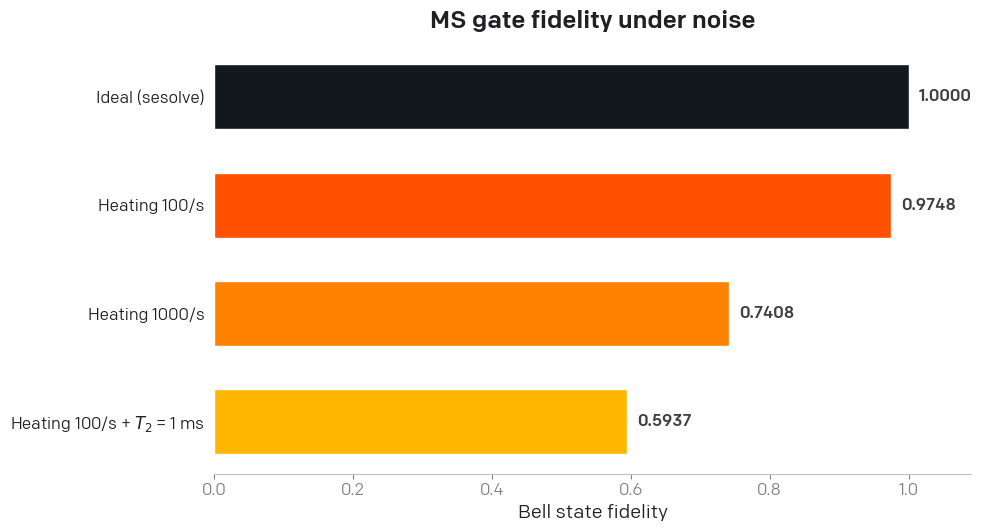

In [8]:
scenarios = {
    "Ideal (sesolve)": dict(solver="sesolve"),
    "Heating 100/s": dict(solver="mesolve", heating_rate=100),
    "Heating 1000/s": dict(solver="mesolve", heating_rate=1000),
    r"Heating 100/s + $T_2$ = 1 ms": dict(solver="mesolve", heating_rate=100, t2_qubit=1e-3),
}

results = {}
for label, kwargs in scenarios.items():
    cfg = SimulationConfig(species=species, trap=trap, n_ions=2, n_modes=1, n_fock=15, **kwargs)
    r = SimulationRunner(cfg)
    res = r.run_ms_gate(ions=[0, 1])
    f = bell_state_fidelity(res.states[-1].ptrace([0, 1]))
    results[label] = f
    print(f"{label:40s} fidelity = {f:.4f}")

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [IONQ_DARK, IONQ_ORANGE, IONQ_MEDIUM_ORANGE, IONQ_LIGHT_ORANGE]
bars = ax.barh(range(len(results)), list(results.values()), color=colors,
               height=0.6, edgecolor=IONQ_WHITE, linewidth=1)
ax.set_yticks(range(len(results)))
ax.set_yticklabels(list(results.keys()), fontsize=12, color=IONQ_BLACK)
ax.set_xlabel("Bell state fidelity", fontsize=14)
ax.set_xlim(0, 1.09)
ax.set_title("MS gate fidelity under noise", fontsize=18, fontweight="medium",
             color=IONQ_BLACK, pad=12)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=12, fontweight="medium",
            color=IONQ_DARK_GREY)
ax.invert_yaxis()
ax.spines["left"].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

## 8. Cooling pipeline

From room temperature (~10^7 phonons) to near ground state in three stages.

In [9]:
from tiqs.cooling.doppler import doppler_cooled_nbar
from tiqs.cooling.eit_cooling import eit_cooling_nbar

# Stage 1: Doppler cooling
n_doppler = doppler_cooled_nbar(species, trap_frequency_hz=1e6)
print(f"Stage 1 - Doppler:  n_bar = {n_doppler:.1f}")

# Stage 2: Sideband cooling (simulated with QuTiP mesolve) - omitted for brevity

# Stage 3: EIT cooling limit (analytical)
n_eit = eit_cooling_nbar(TWO_PI * 200e3, TWO_PI * 1e6, carrier_suppression=0.01)
print(f"Stage 3 - EIT:      n_bar = {n_eit:.4f}")

Stage 1 - Doppler:  n_bar = 11.2
Stage 3 - EIT:      n_bar = 0.0010


## 9. Measurement

Joint Born-rule sampling preserves entanglement correlations. Independent per-ion sampling destroys them.

In [10]:
from tiqs.spam.measurement import sample_measurement
from collections import Counter

rho_bell = result_ms.states[-1]
rng = np.random.default_rng(42)

shots = 1000
outcomes = [tuple(sample_measurement(rho_bell, [0, 1], rng)) for _ in range(shots)]
counts = Counter(outcomes)

print("Bell state measurement (1000 shots):")
for state in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    label = f"|{''.join(str(b) for b in state)}>"
    print(f"  {label}: {counts.get(state, 0):4d}")
print(f"\nCorrelated outcomes (00 + 11): {counts.get((0,0), 0) + counts.get((1,1), 0)}")

Bell state measurement (1000 shots):
  |00>:  503
  |01>:    0
  |10>:    0
  |11>:  497

Correlated outcomes (00 + 11): 1000


## Summary

Mathieu stability -> Coulomb equilibria -> Hessian eigendecomposition ->
Lamb-Dicke parameters -> interaction-picture Hamiltonians ->
phase-space loop closure -> six Lindblad channels -> sesolve

**The physics is real. The simulator is open source. Every formula is validated.**

`github.com/splch/tiqs`